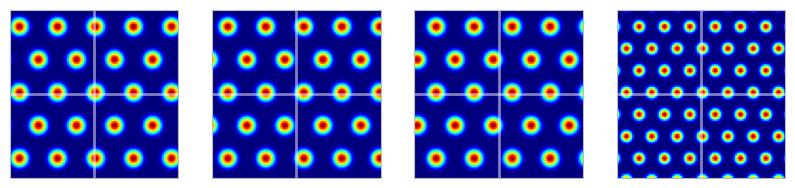

In [1]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('bmh')
import pickle
import os

OUTPUT_DIR = 'simulation_outputs'

DISK_RADIUS = 0.6

s = 0.9           # Scale (i.e., distance between two peaks)
r = np.pi / 2   # Orientation
o_x = 0           # x offset
o_y = 0           # y offset

def gc(X,Y,s,r,o_x,o_y):
    '''Computes grid cell rate map for X and Y coordinates.'''
    mult = 1
    for d in range(3):
        mult *= 1 + np.cos((X - o_x) * ((2 * np.pi) / s) * np.cos(r + d * np.pi / 3) * (2 / np.sqrt(3))
                            + (Y - o_y) * ((2 * np.pi) / s) * np.sin(r + d * np.pi / 3) * (2 / np.sqrt(3)))
    mult = mult - 0.2
    return np.clip(mult, 0, None)

arena_width = 4
resolution = 0.05
x = np.arange(- arena_width / 2, arena_width / 2, resolution)
y = np.arange(- arena_width / 2, arena_width / 2, resolution)
X,Y = np.meshgrid(x, y)

Z_1 = gc(X, Y, s=s, r=r, o_x=o_x, o_y=o_y)
Z_2 = gc(X, Y, s=s, r=r, o_x=0.15, o_y=0)
Z_3 = gc(X, Y, s=s, r=r, o_x=0.30, o_y=0)
Z_4 = gc(X, Y, s=0.6, r=r, o_x=o_x, o_y=o_y)
Zs = [Z_1, Z_2, Z_3, Z_4]

def plot_grid_cell_maps(Zs, arena_width):
    n_maps = len(Zs)
    fig, axs = plt.subplots(1, n_maps, figsize=(2.5 * n_maps, 4))
    axs = [axs] if n_maps == 1 else axs
    for i in range(n_maps):
        axs[i].imshow(Zs[i], extent=(-arena_width/2, arena_width/2, -arena_width/2, arena_width/2), origin='lower', cmap='jet')
        axs[i].vlines(0, color='white', alpha=0.5, ymin=-arena_width/2, ymax=arena_width/2)
        axs[i].hlines(0, color='white', alpha=0.5, xmin=-arena_width/2, xmax=arena_width/2)
        axs[i].set_xticks([])
        axs[i].set_yticks([])
 
    plt.show()
plot_grid_cell_maps(Zs, arena_width)

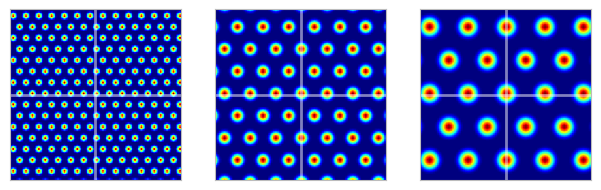

In [2]:
Z_1 = gc(X, Y, s=0.3, r=r, o_x=o_x, o_y=o_y)
Z_2 = gc(X, Y, s=0.6, r=r, o_x=o_x, o_y=o_y)
Z_3 = gc(X, Y, s=0.9, r=r, o_x=o_x, o_y=o_y)
plot_grid_cell_maps([Z_1, Z_2, Z_3], arena_width)

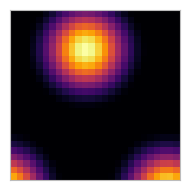

In [2]:

def module_matrix(x,y,s,r,arena_width=arena_width, resolution=0.15):
    mat_width = int(arena_width / resolution)
    o_xs = np.linspace(0, s, mat_width)
    o_ys = np.linspace(0, -s, mat_width)
    o_xs, o_ys = np.meshgrid(o_xs, o_ys)
    mat_activations = np.zeros((mat_width, mat_width))
    for cell_i in range(mat_width):
        # in reversed order to have the origin at the bottom left corner of the plot
        for cell_j in range(mat_width):
            mat_activations[cell_i, cell_j] = gc(x, y, s=s, r=r, o_x=o_xs[cell_i, cell_j], o_y=o_ys[cell_i, cell_j])
    return np.flip(mat_activations, axis=0)

def plot_mat(im):
    plt.figure(figsize=(2, 2))
    plt.imshow(im, origin='lower', cmap='inferno')
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()

plot_mat(module_matrix(0.4,-0.2,s,r))

Current matrix:


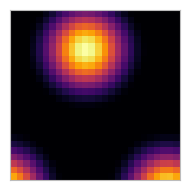

Population vector: [-0.85918936  0.51165774]


In [3]:
def similarity_score(curr_mat, template_mat):
    return np.round(curr_mat.flatten().dot(template_mat.flatten()) / (np.linalg.norm(curr_mat.flatten()) * np.linalg.norm(template_mat.flatten())), decimals=3)

def population_vector(curr_mat, s, r, step_size = 0.2):
    # Get all detector vectors based on the specified angles and step size
    detector_angles_deg = np.array([0, 30, 60, 90, 120, 150, 180, 210, 240, 270, 300, 330])
    detector_xs = np.round([-np.cos(np.deg2rad(angle)) * step_size for angle in detector_angles_deg], decimals=3)
    detector_ys = np.round([-np.sin(np.deg2rad(angle)) * step_size for angle in detector_angles_deg], decimals=3)

    # Calculate the population vector as the average of each detector vectors...
    pupulation_vector = []
    for i in range(len(detector_xs)):
        detector_vec = np.array([detector_xs[i], detector_ys[i]])
        detector_mat = module_matrix(detector_vec[0], detector_vec[1], s, r)
        detector_score = similarity_score(detector_mat, curr_mat)
        #... weighted by their similarity score with the current matrix
        pupulation_vector.append(-detector_vec * detector_score)
       # plot_mat(detector_mat)
    pupulation_vector = np.array(pupulation_vector).sum(axis=0) / len(pupulation_vector)
    pupulation_vector = pupulation_vector / np.linalg.norm(pupulation_vector)  # Normalize the population vector
    return pupulation_vector

curr_mat = module_matrix(0.4,-0.2,s,r)
print("Current matrix:")
plot_mat(curr_mat)
pop_vec = population_vector(curr_mat, s, r)
print(f"Population vector: {pop_vec}")



Distorted Grid Cells

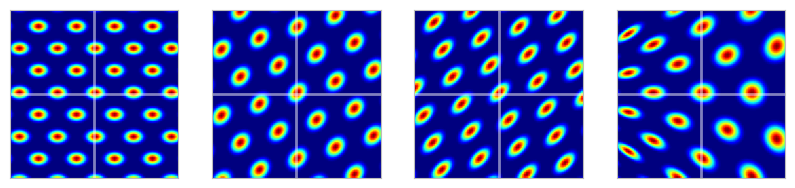

In [4]:
def gc_distortion(X, Y, distortion, a=None, b=None):
    '''Applied distortion to X and Y coordinates.'''
    if distortion == 'stretch':
        dist_mat = np.array([[a, 0], [0, b]])
        inv_dist_mat = np.linalg.inv(dist_mat)
        X_new = inv_dist_mat[0,0]*X + inv_dist_mat[0,1]*Y
        Y_new = inv_dist_mat[1,0]*X + inv_dist_mat[1,1]*Y
    elif distortion == 'shear':
        dist_mat = np.array([[1, a], [b, 1]])
        inv_dist_mat = np.linalg.inv(dist_mat)
        X_new = inv_dist_mat[0,0]*X + inv_dist_mat[0,1]*Y
        Y_new = inv_dist_mat[1,0]*X + inv_dist_mat[1,1]*Y
    elif distortion == 'symmetric':
        X_new = X / (1 + a)
        Y_new = Y / (1 + (a * X / (1 + a)))  
    return X_new, Y_new

# Distortion 1
X_stretch, Y_stretch = gc_distortion(X, Y, distortion = 'stretch', a=1, b=0.67)
Z_STRETCH = gc(X_stretch, Y_stretch, s=s, r=r, o_x=o_x, o_y=o_y)

# Distortion 2
X_shear, Y_shear = gc_distortion(X, Y, distortion = 'shear', a=0, b=0.3)
Z_SHEAR_1 = gc(X_shear, Y_shear, s=s, r=r, o_x=o_x, o_y=o_y)

# Distortion 2
X_shear, Y_shear = gc_distortion(X, Y, distortion = 'shear', a=0.3, b=0.3)
Z_SHEAR_2 = gc(X_shear, Y_shear, s=s, r=r, o_x=o_x, o_y=o_y)

# Distortion 4
X_symm, Y_symm = gc_distortion(X, Y, distortion = 'symmetric', a=0.3)
Z_SYM = gc(X_symm, Y_symm, s=s, r=r, o_x=o_x, o_y=o_y)

plot_grid_cell_maps([Z_STRETCH, Z_SHEAR_1, Z_SHEAR_2, Z_SYM], arena_width)

In [5]:
def simulation(n_trials=10, step_size = 0.01, convergence_threshold = 0.025, distortion=None, a=0, b=0, verbose=False):
    x_histories = []
    y_histories = []
    for i in range(n_trials):
     
        print(f"Trial {i+1}/{n_trials}")
        # Sample a random starting position within the disk
        sampled_angle = np.random.uniform(0, 2 * np.pi)
        sampled_radius = DISK_RADIUS * np.sqrt(np.random.uniform(0, 1)) 
        x = sampled_radius * np.cos(sampled_angle)
        y = sampled_radius * np.sin(sampled_angle)
        if distortion is not None:
            x, y = gc_distortion(x, y, distortion=distortion, a=a, b=b)
            
        # Conduct simulations for ten steps
        x_history = [x]
        y_history = [y]
        converged = False
        step_count = 0
        while not converged:
            # Calculate population vector for the current position

            if distortion is not None:
                new_x, new_y = gc_distortion(x_history[-1], y_history[-1], distortion=distortion, a=a, b=b)
            curr_mat = module_matrix(new_x, new_y, s, r)
            curr_pop_vec = population_vector(curr_mat, s, r)

            # Update position based on the population vector
            new_x = x_history[-1] + (curr_pop_vec[0] * step_size)
            new_y = y_history[-1] + (curr_pop_vec[1] * step_size)
            if verbose:
                print(f"Step {step_count}: Position ({new_x:.3f}, {new_y:.3f})")
    
            x_history.append(new_x)
            y_history.append(new_y)

            # Check for convergence only after five steps
            if step_count > 5:
                old_x = x_history[-5]
                old_y = y_history[-5]
                distance_moved = np.sqrt((new_x - old_x) ** 2 + (new_y - old_y) ** 2)
                if distance_moved < convergence_threshold:
                    converged = True
            step_count += 1
        x_histories.append(x_history)
        y_histories.append(y_history)
    return x_histories, y_histories

def plot_trajectories(x_histories, y_histories):
    n_trials = len(x_histories)
    plt.figure(figsize=(6, 6))

    # Draw disk boundary
    circle = plt.Circle((0, 0), DISK_RADIUS, color='black', alpha=0.5, linestyle='--', fill=False)
    plt.gca().add_patch(circle)

    success_count = 0
    for trial in range(n_trials):
        last_x = x_histories[trial][-1]
        last_y = y_histories[trial][-1]
        success = np.sqrt(last_x**2 + last_y**2) <= 0.1
        color = 'blue' if success else 'red'
        success_count += success
        plt.plot(x_histories[trial], y_histories[trial], color=color, markersize=0.001)
    plt.xlim(-1, 1)
    plt.ylim(-1, 1)
    plt.xticks([])
    plt.yticks([])
    plt.axhline(0, color='gray', lw=0.5)
    plt.axvline(0, color='gray', lw=0.5)

    plt.show()
    print(f'Successful trials: {success_count}/{n_trials} ({(success_count/n_trials)*100:.1f}%)')

Loading simulation data from simulation_outputs/simulation_trials-400.pkl


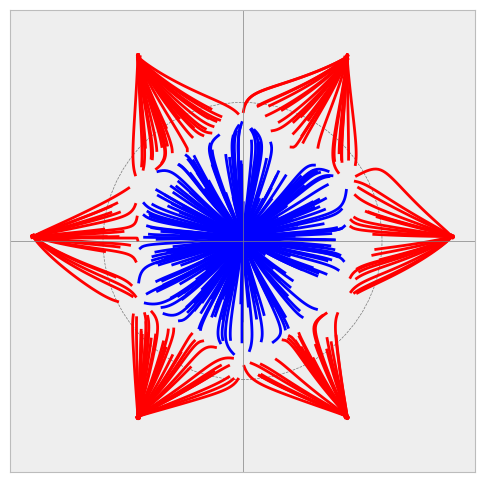

Successful trials: 249/400 (62.3%)


In [6]:
# import Path from pathlib
from pathlib import Path

def run_load_simulation(n_trials=400, distortion = None, a=None, b=None):
    distortion_text = f'_{distortion}_a-{a}_b-{b}' if distortion is not None else ''
    simulation_data_file = Path(OUTPUT_DIR) / f'simulation_trials-{n_trials}{distortion_text}.pkl'
    if not os.path.exists(simulation_data_file):
        print('Running new simulation...')
        x_histories, y_histories = simulation(n_trials=n_trials, distortion=distortion, a=a, b=b)
        plot_trajectories(x_histories, y_histories)
        with open(simulation_data_file, 'wb') as f:
            pickle.dump((x_histories, y_histories), f) 
            print(f'Saved simulation data to {simulation_data_file}')
    else: 
        print(f'Loading simulation data from {simulation_data_file}')
        x_histories, y_histories = pickle.load(open(simulation_data_file, 'rb'))
        return [x_histories, y_histories]
x_histories, y_histories = run_load_simulation(n_trials=400, distortion = None, a=None, b=None)
plot_trajectories(x_histories, y_histories)
    

Running new simulation...
Trial 1/400
Trial 2/400
Trial 3/400
Trial 4/400
Trial 5/400
Trial 6/400
Trial 7/400
Trial 8/400
Trial 9/400
Trial 10/400
Trial 11/400
Trial 12/400
Trial 13/400
Trial 14/400
Trial 15/400
Trial 16/400
Trial 17/400
Trial 18/400
Trial 19/400
Trial 20/400
Trial 21/400
Trial 22/400
Trial 23/400
Trial 24/400
Trial 25/400
Trial 26/400
Trial 27/400
Trial 28/400
Trial 29/400
Trial 30/400
Trial 31/400
Trial 32/400
Trial 33/400
Trial 34/400
Trial 35/400
Trial 36/400
Trial 37/400
Trial 38/400
Trial 39/400
Trial 40/400
Trial 41/400
Trial 42/400
Trial 43/400
Trial 44/400
Trial 45/400
Trial 46/400
Trial 47/400
Trial 48/400
Trial 49/400
Trial 50/400
Trial 51/400
Trial 52/400
Trial 53/400
Trial 54/400
Trial 55/400
Trial 56/400
Trial 57/400
Trial 58/400
Trial 59/400
Trial 60/400
Trial 61/400
Trial 62/400
Trial 63/400
Trial 64/400
Trial 65/400
Trial 66/400
Trial 67/400
Trial 68/400
Trial 69/400
Trial 70/400
Trial 71/400
Trial 72/400
Trial 73/400
Trial 74/400
Trial 75/400
Trial 76

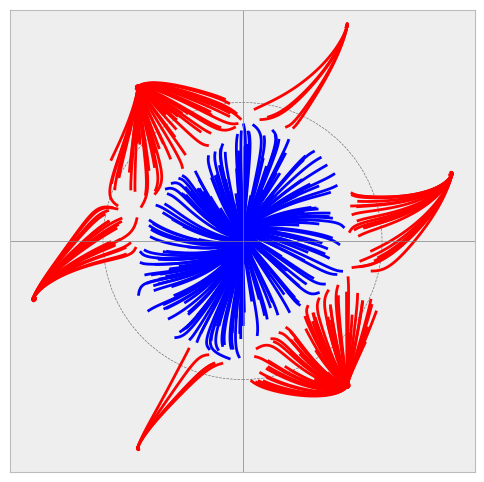

Successful trials: 231/400 (57.8%)
Saved simulation data to simulation_outputs/simulation_trials-400_shear_a-0_b-0.3.pkl


TypeError: cannot unpack non-iterable NoneType object

In [7]:
x_histories, y_histories = run_load_simulation(n_trials=400, distortion = 'shear', a=0, b=0.3)
plot_trajectories(x_histories, y_histories)
